<a href="https://colab.research.google.com/github/e-akselrod/momentum-backtest/blob/main/Momentum_Backtest.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Momentum Strategy Backtest

A cross-sectional momentum strategy on large-cap US stocks, backtested honestly. Each month it ranks the stocks by recent trend, buys the strongest, holds for a month, and repeats.

The point isn't the return. It's testing the thing without fooling yourself, which is where most backtests fall apart. Three things keep it honest here: signals only ever use past data (no lookahead), trades cost money (charged on turnover), and it's measured against real benchmarks instead of its own return.

Data: monthly adjusted prices from Yahoo Finance via yfinance. No account or API key needed.

Steps:
1. Pick the universe and set the parameters.
2. Pull monthly prices.
3. Build the momentum signal.
4. Form the portfolio each month and charge costs.
5. Measure it (Sharpe, drawdown, return) against benchmarks.
6. Plot the equity curve and drawdowns.
7. Read the results, limitations included.

## Step 1. Universe and settings

Installs yfinance and defines the basket: 25 large, liquid US stocks across tech, finance, healthcare, energy, consumer, and industrials. Three knobs define the strategy: how far back to pull data, the trading cost in basis points, and how much of the basket to hold (the top fifth).

In [1]:
!pip install -q yfinance

import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# A diversified basket of large, liquid US stocks.
UNIVERSE = [
    "AAPL", "MSFT", "GOOGL", "AMZN", "META", "NVDA",     # technology / communications
    "JPM", "BAC", "GS",                                  # financials
    "JNJ", "PFE", "UNH", "MRK",                           # healthcare
    "XOM", "CVX",                                         # energy
    "PG", "KO", "PEP", "WMT",                             # staples / retail
    "HD", "MCD", "NKE",                                   # consumer discretionary
    "CAT", "BA",                                          # industrials
    "DIS",                                                # media
]

START = "2010-01-01"     # how far back to pull prices
COST_BPS = 10            # trading cost in basis points, charged on the amount traded
TOP_FRACTION = 0.20      # each month, hold the top fifth by momentum

print(len(UNIVERSE), "stocks in the universe")

25 stocks in the universe


## Step 2. Pull prices

Monthly prices for the basket plus SPY (the market benchmark), adjusted for dividends and splits. Monthly returns come straight off those prices and feed everything below.

In [2]:
raw = yf.download(UNIVERSE + ["SPY"], start=START, interval="1mo",
                  auto_adjust=True, progress=False)["Close"]

prices = raw[UNIVERSE]        # monthly adjusted close for our basket
spy = raw["SPY"]              # market benchmark

monthly_ret = prices.pct_change()
spy_ret = spy.pct_change()

print("Downloaded", prices.shape[1], "stocks,", prices.shape[0], "months,",
      prices.index.min().date(), "to", prices.index.max().date())

Downloaded 25 stocks, 198 months, 2010-01-01 to 2026-06-01


## Step 3. The momentum signal

We rank stocks by their return over the 12 months ending one month ago. Skipping the most recent month is deliberate: over a few weeks stocks tend to reverse, so including it muddies the signal. This 12-minus-1 window is the standard momentum definition.

The part that matters is the `shift(1)`: the signal on any date only sees prices from a month earlier, so it can't peek at the return we're about to try to capture. That's the no-lookahead guarantee, and it's the whole game in a backtest.

In [3]:
# 12-1 momentum: each stock's total return over the 12 months ending one month ago.
# prices.shift(1) means the signal on any date only sees prices from a month earlier,
# so it can never use the return we are about to try to earn (no lookahead).
signal = prices.shift(1).pct_change(12)

print("Momentum signal built. Strongest stocks in the most recent month:")
print(signal.iloc[-1].dropna().nlargest(5).round(3))

Momentum signal built. Strongest stocks in the most recent month:
Ticker
CAT      1.544
GOOGL    1.222
GS       0.743
MRK      0.601
NVDA     0.563
Name: 2026-06-01 00:00:00, dtype: float64


## Step 4. Build the portfolio, charge costs

Each month, rank by the signal and buy the top fifth, equal-weighted. The `shift(1)` on the weights is what stops cheating: positions chosen from a given month's data are held the next month and earn that month's return. Decide first, collect after.

Trading isn't free. Every time the target weights change we pay 10 bps on the amount traded. Momentum turns over a lot, so this isn't negligible, and the gap between the gross and net results is exactly what the trading costs you.

In [4]:
# Each month, rank the stocks that have a signal and hold the top fifth, equal-weighted.
def pick_top(row):
    s = row.dropna()
    w = pd.Series(0.0, index=row.index)
    if len(s) < 5:
        return w
    n = max(3, int(round(TOP_FRACTION * len(s))))
    w[s.nlargest(n).index] = 1.0 / n
    return w

weights = signal.apply(pick_top, axis=1)

# NO LOOKAHEAD: holdings chosen using data up to a month are held the FOLLOWING month.
# weights.shift(1) lines up last month's decision with this month's realized return.
gross_return = (weights.shift(1) * monthly_ret).sum(axis=1)

# Trading costs: when the target weights change, pay a cost on the amount traded.
cost_rate = COST_BPS / 10000.0
turnover = weights.diff().abs().sum(axis=1)          # total change in weights at each rebalance
cost = (turnover * cost_rate).shift(1)               # cost lands in the month the trade takes effect
net_return = gross_return - cost.fillna(0.0)

print("Average turnover: {:.0f}% of the portfolio per year".format(turnover.mean() * 12 * 100))

Average turnover: 513% of the portfolio per year


## Step 5. Measure it

Compared against two benchmarks: an equal-weight basket of the same stocks (rebalanced monthly) and SPY for the broad market. Four numbers: annual return (CAGR), annualized volatility, Sharpe (return per unit of risk, with a zero risk-free rate here), and max drawdown (worst peak-to-trough fall).

Return on its own is misleading, since you can always earn more by taking more risk. Sharpe and drawdown are what tell you whether the extra return was worth it.

In [5]:
# Fair benchmarks: an equal-weight basket of the same names, and the market (SPY).
equal_weight = monthly_ret.mean(axis=1)

# Start the comparison from the first month the strategy actually holds something.
first_held = (weights.shift(1).abs().sum(axis=1) > 0).idxmax()
window = prices.index[prices.index >= first_held]

series = {
    "Momentum (net)": net_return,
    "Momentum (gross)": gross_return,
    "Equal-weight basket": equal_weight,
    "SPY (buy & hold)": spy_ret,
}
series = {k: v.reindex(window).dropna() for k, v in series.items()}

# Keep only the months that every series shares, so the comparison is apples to apples.
common = series["Momentum (net)"].index
for v in series.values():
    common = common.intersection(v.index)
series = {k: v.loc[common] for k, v in series.items()}

def performance(r):
    n = len(r)
    cum = (1 + r).prod()
    eq = (1 + r).cumprod()
    return pd.Series({
        "CAGR": cum ** (12 / n) - 1,
        "Volatility": r.std() * np.sqrt(12),
        "Sharpe": (r.mean() * np.sqrt(12)) / r.std(),
        "Max drawdown": (eq / eq.cummax() - 1).min(),
    })

summary = pd.DataFrame({name: performance(r) for name, r in series.items()}).T

# Format for readability
table = summary.copy()
for col in ["CAGR", "Volatility", "Max drawdown"]:
    table[col] = (table[col] * 100).round(1).astype(str) + "%"
table["Sharpe"] = table["Sharpe"].round(2)

print("Backtest window:", common[0].date(), "to", common[-1].date(),
      "({} months)".format(len(common)))
table

Backtest window: 2011-03-01 to 2026-06-01 (184 months)


,CAGR,Volatility,Sharpe,Max drawdown
Momentum (net),23.4%,18.2%,1.25,-21.9%
Momentum (gross),24.1%,18.2%,1.28,-21.8%
Equal-weight basket,17.6%,13.9%,1.25,-21.1%
SPY (buy & hold),13.9%,14.5%,0.97,-24.0%


## Step 6. Charts

Growth of $1 on a log scale (so equal percentage moves look the same anywhere on the chart), and the strategy's drawdown over time, which is the part that's actually hard to sit through.

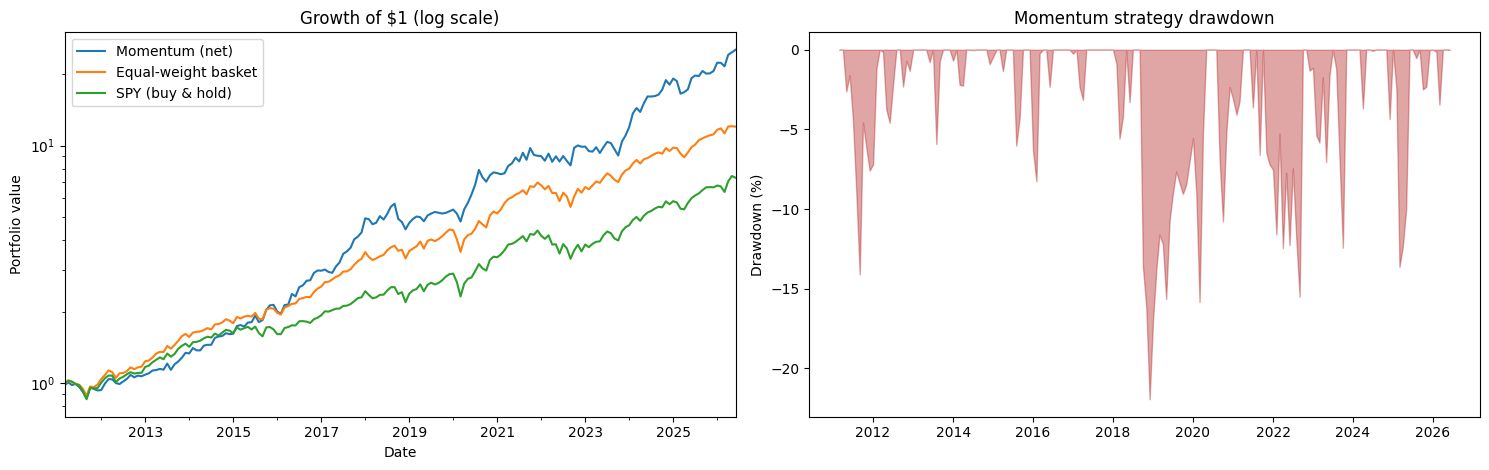

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(15, 4.8))

# Equity curves
for name in ["Momentum (net)", "Equal-weight basket", "SPY (buy & hold)"]:
    (1 + series[name]).cumprod().plot(ax=axes[0], label=name)
axes[0].set_yscale("log")
axes[0].set_title("Growth of $1 (log scale)")
axes[0].set_ylabel("Portfolio value")
axes[0].legend()

# Drawdown of the net strategy
eq = (1 + series["Momentum (net)"]).cumprod()
drawdown = (eq / eq.cummax() - 1) * 100
axes[1].fill_between(drawdown.index, drawdown.values, 0, color="firebrick", alpha=0.4)
axes[1].set_title("Momentum strategy drawdown")
axes[1].set_ylabel("Drawdown (%)")

plt.tight_layout()
plt.show()

## Step 7. Results and limitations

Read the table and charts from your run for the exact figures. The shape of it: the strategy clearly beats SPY, but against an equal-weight basket of the same names the risk-adjusted edge is thin. Momentum delivered more, but mostly by taking more risk and trading more, and a fair benchmark eats most of the apparent advantage. The gross-versus-net gap is the price of all that trading.

The limitations matter, and a quant interviewer will ask about them:

- Survivorship bias. The basket is today's winners. Stocks that blew up or got delisted aren't in it, which flatters everything here, the benchmarks included. The honest fix is a point-in-time universe (index membership as it actually stood each month).
- Costs are a flat estimate. Real ones include the bid-ask spread, market impact, and slippage, so true costs run higher.
- Nothing was tuned out of sample. The 12-month lookback, monthly rebalance, and top-fifth cutoff are standard but weren't validated on separate data.
- Monthly bars hide whatever happens within the month.

Where I'd take it next: add a short side (sell the bottom fifth) to make it roughly market-neutral and see if Sharpe improves; test on a point-in-time universe to kill the survivorship bias; or cut exposure when volatility spikes and check the effect on drawdown.

## Step 8. What it would buy now

The strategy's picks for the most recent month in the data, equal-weighted. A quick gut check that the holdings look reasonable.

In [7]:
latest = signal.iloc[-1].dropna()
n = max(3, int(round(TOP_FRACTION * len(latest))))
picks = latest.nlargest(n)

print("Most recent rebalance date:", signal.index[-1].date())
print("Holdings for next month, equal-weight at {:.0f}% each:".format(100 / n))
picks.round(3).rename("12-month momentum").to_frame()

Most recent rebalance date: 2026-06-01
Holdings for next month, equal-weight at 20% each:


,12-month momentum
Ticker,
CAT,1.544
GOOGL,1.222
GS,0.743
MRK,0.601
NVDA,0.563
